In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
def load_csv(csv_file):
    data = np.genfromtxt(csv_file, delimiter=",", skip_header=1)
    t = np.asarray(data[:, 0], dtype=np.float32)
    ch1 = np.asarray(data[:, 1], dtype=np.float32)
    # ch2 = np.asarray(data[:, 2], dtype=np.float32)
    return t, ch1

def compute_fft(t, y):
    dt = t[1] - t[0]
    N = len(y)
    Y = np.fft.fft(y)
    f = np.fft.fftfreq(N, d=dt)

    Y = np.fft.fftshift(Y)
    f = np.fft.fftshift(f)

    return f, np.abs(Y / len(y))

def get_peak_freq(t, y):
    mask = t > 0
    f, Y = compute_fft(t[mask], y[mask])
    Y = np.abs(Y)
    return np.abs(f[np.argmax(Y)]) / 1e6

(-2.5e-06, 2.5e-06)

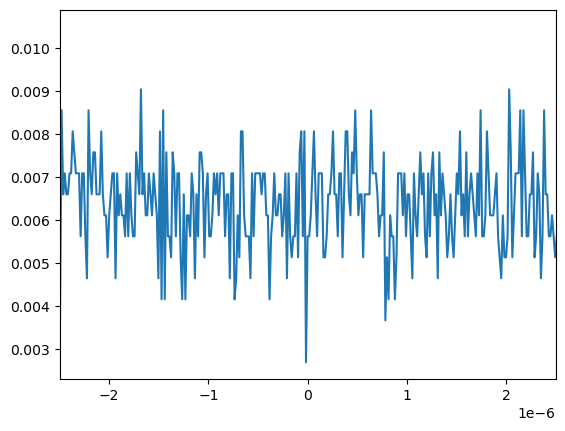

In [15]:
t, ch1 = load_csv("D:/data/WFM01.CSV")
fig, ax = plt.subplots()
ax.plot(t, ch1)
ax.set_xlim([-0.25e-5, 0.25e-5])

# f, Y = compute_fft(t, ch1)
# fig, ax = plt.subplots()
# ax.plot(f, Y)
# print(get_peak_freq(t, ch1))

10000
33.125


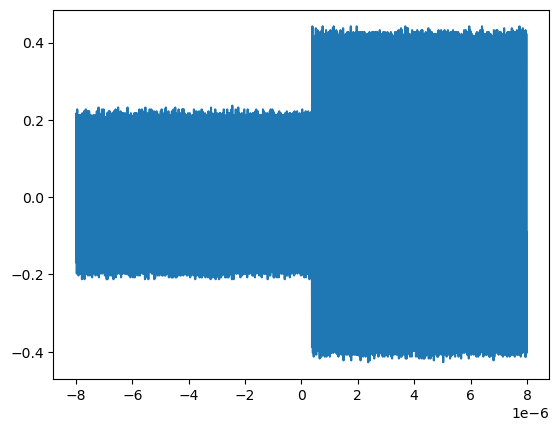

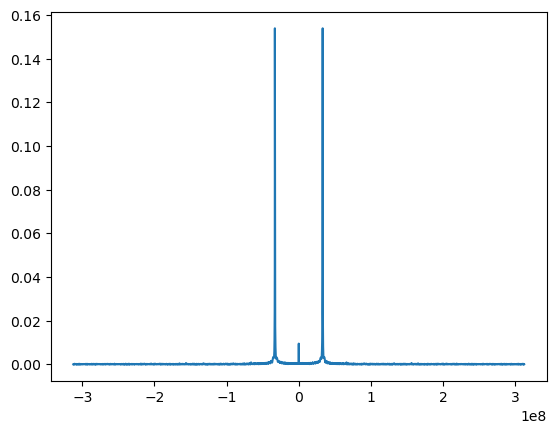

In [39]:
t, ch1 = load_csv("D:/data/WFM07.CSV")
print(len(t))
fig, ax = plt.subplots()
ax.plot(t, ch1)
# ax.plot(t[t<0], ch1[t<0])
# ax.set_xlim([-0.25e-5, 0])

# fig, ax = plt.subplots()
# ax.plot(t[t>0], ch1[t>0])
# ax.set_xlim([0, 0.25e-5])

print(get_peak_freq(t, ch1))



5.625
5.375
38.875
33.125
22.5
22.25
43.125
5.25
35.125
10.875
5.625
5.375
38.875
33.125
22.5


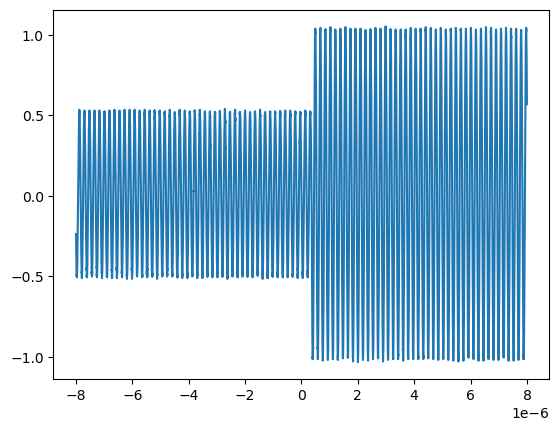

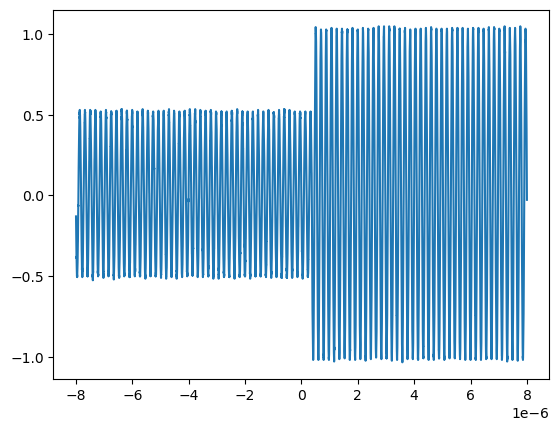

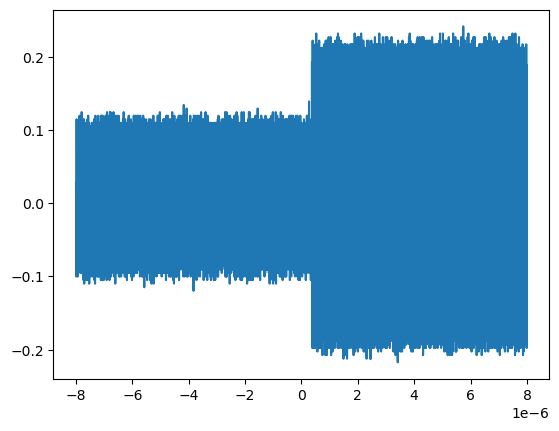

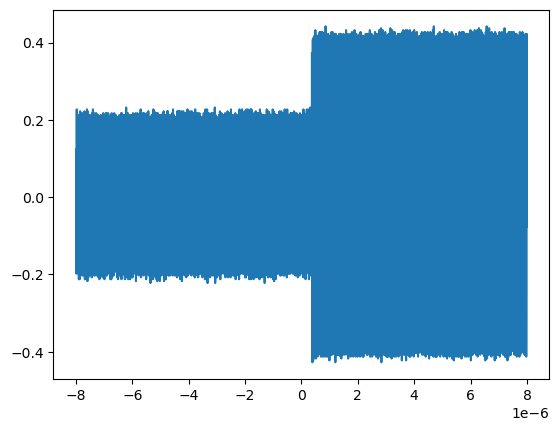

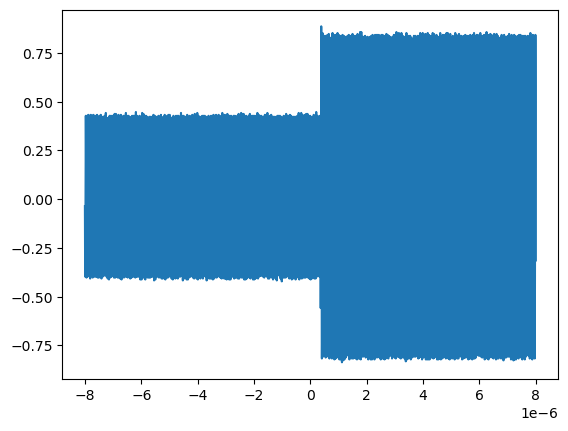

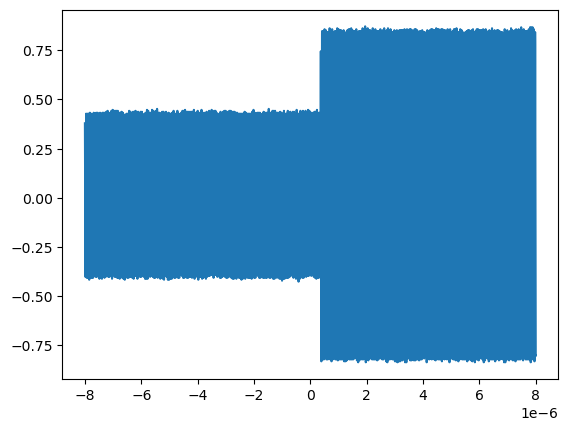

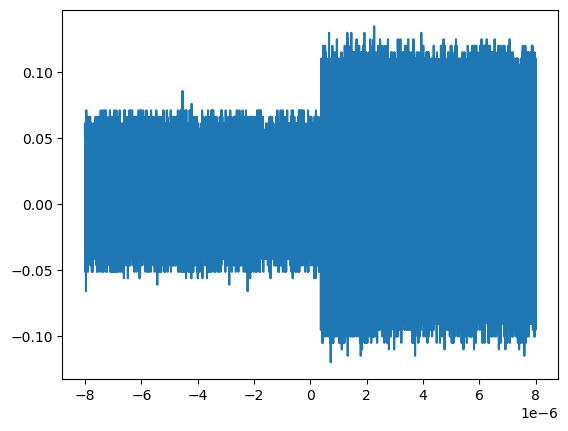

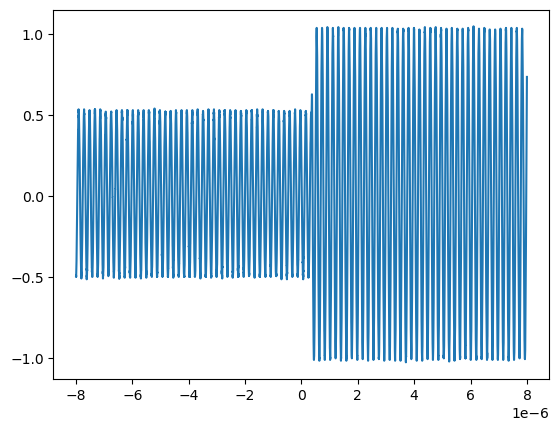

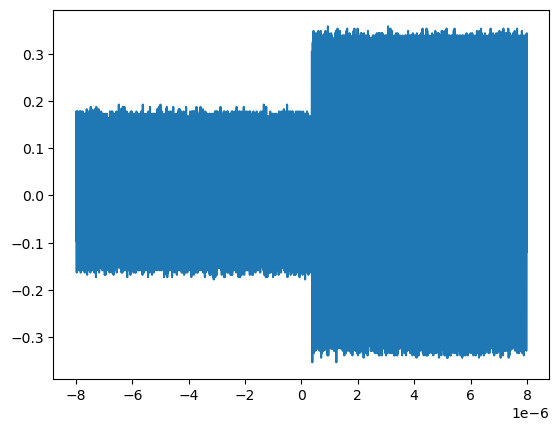

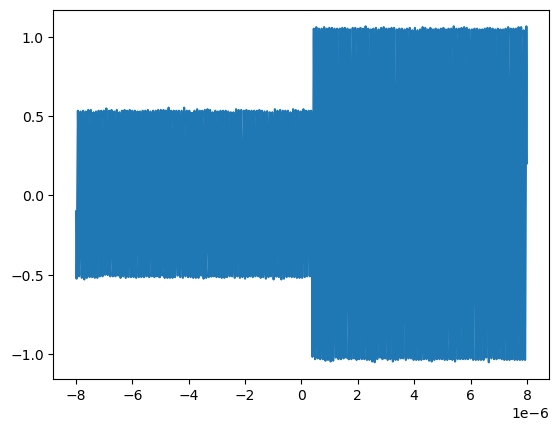

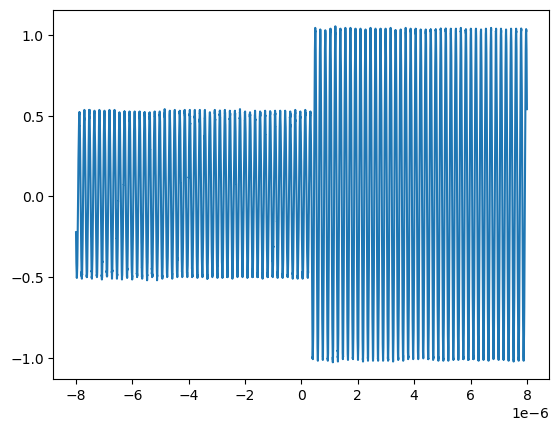

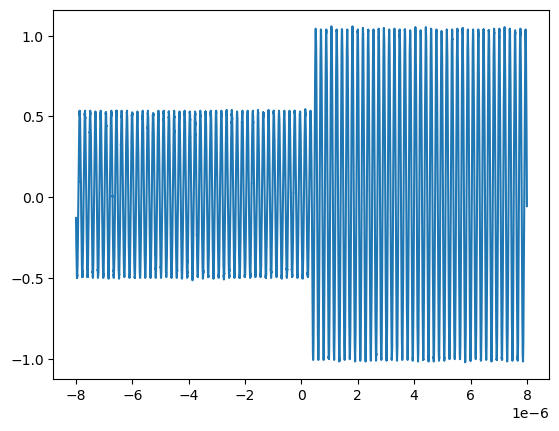

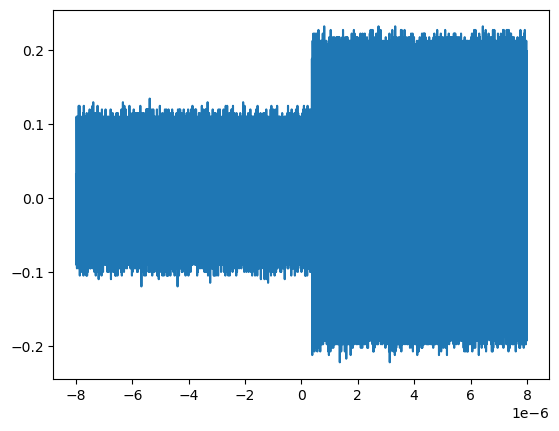

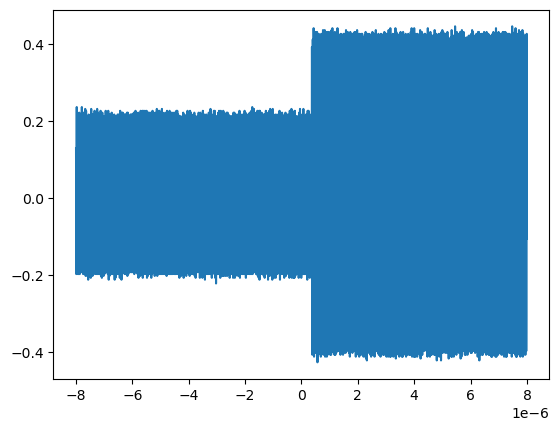

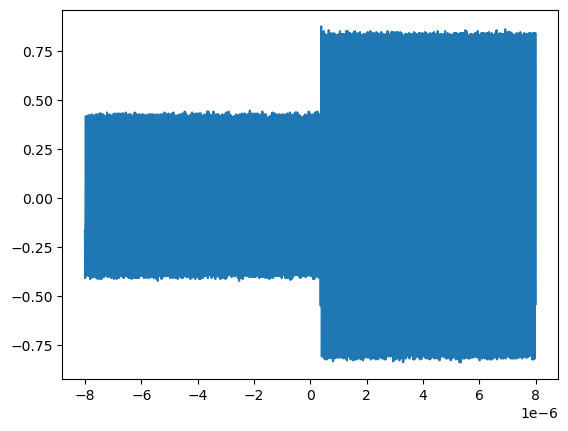

In [65]:
# [ 5.373296 38.923847 33.074005 22.505043 22.217746 43.071298  5.211336
#  35.171034 10.872007  5.61469 ]
for i in range(1, 16):
    t, ch1 = load_csv(f"D:/data/WFM0{i}.CSV")
    print(get_peak_freq(t, ch1))
    fig, ax = plt.subplots()
    ax.plot(t, ch1)


In [97]:
t, ch1 = load_csv(f"./data/WFM01.CSV")
print(t)
sample_rate = 2.5e9 / 4
dt = (1 / sample_rate)
t_new = np.arange(-10000 / 2, 10000 / 2, 1) * dt 
print(t_new - t)

[-8.0000e-06 -7.9984e-06 -7.9968e-06 ...  7.9952e-06  7.9968e-06
  7.9984e-06]
[-2.01980580e-14  1.78621524e-13  3.77441103e-13 ...  3.33234017e-13
 -3.77441103e-13 -1.78621524e-13]


22.254450890178035
43.13362672534507
5.251050210042008
35.13202640528106
10.877175435087018
5.626125225045009
5.3760752150430084
38.88277655531106
33.13162632526505
22.504500900180037
22.254450890178035
43.13362672534507
5.251050210042008
35.13202640528106
10.877175435087018


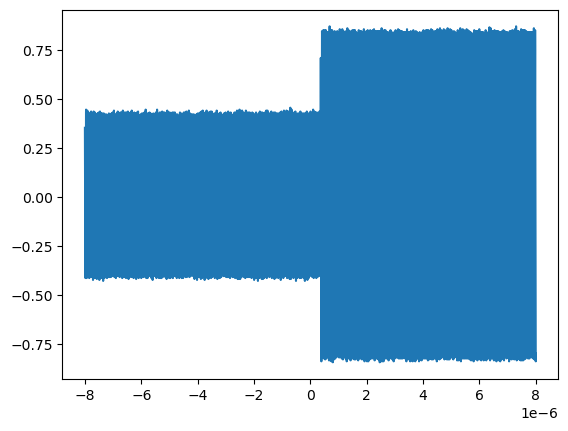

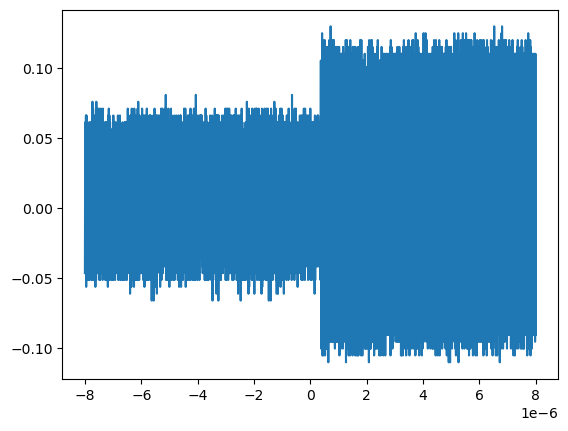

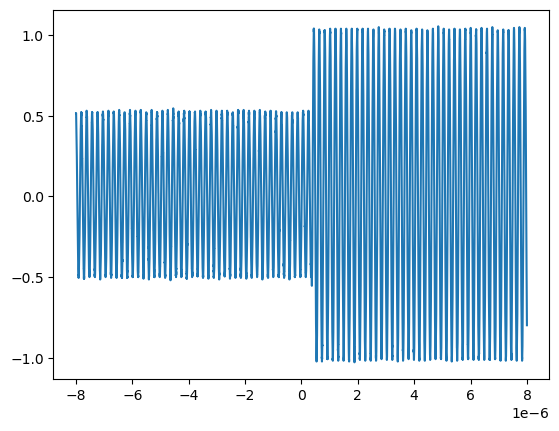

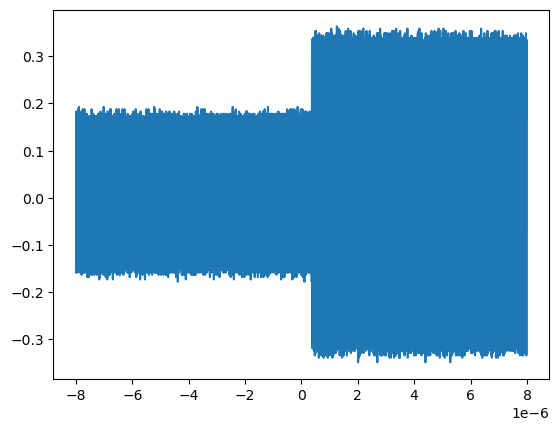

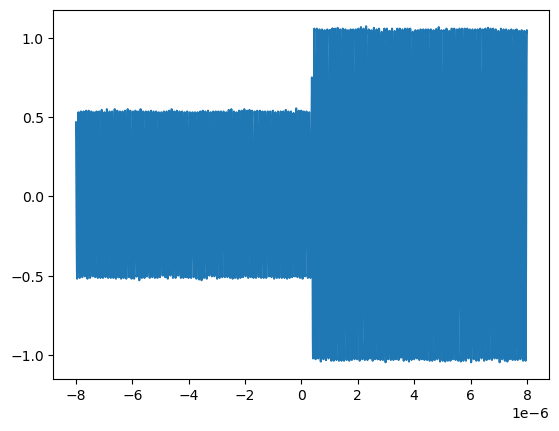

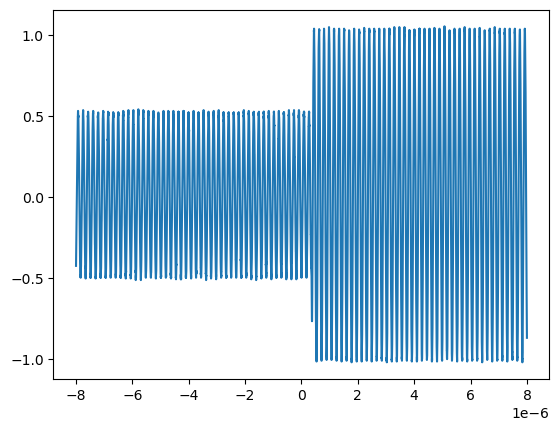

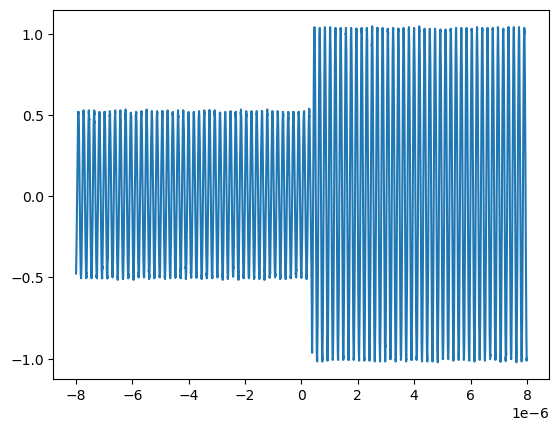

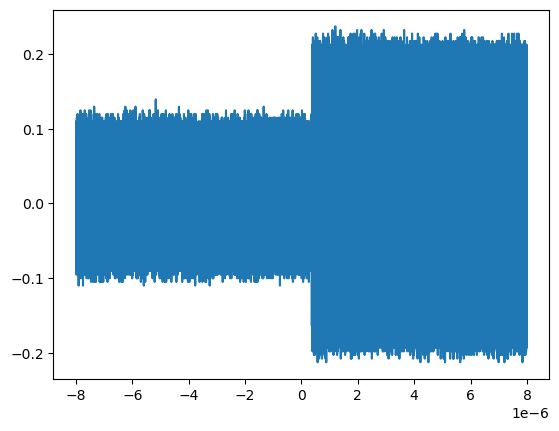

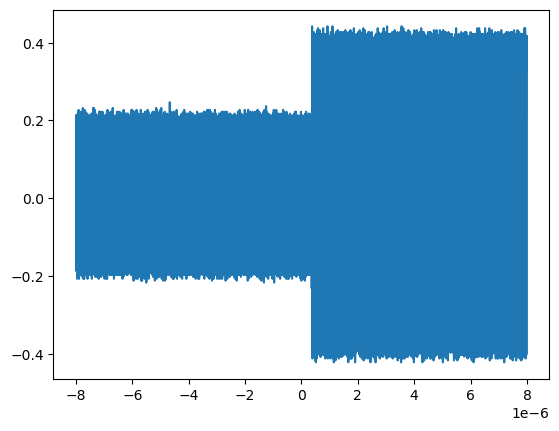

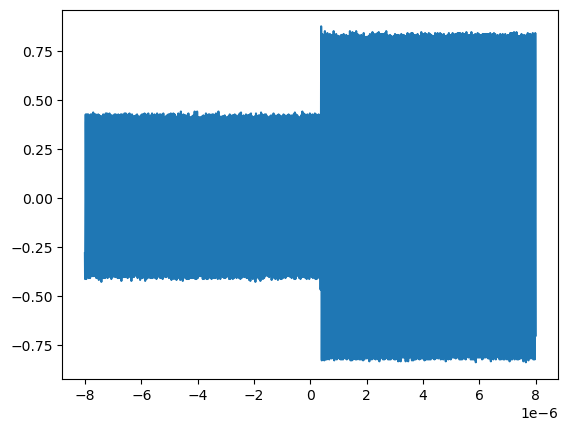

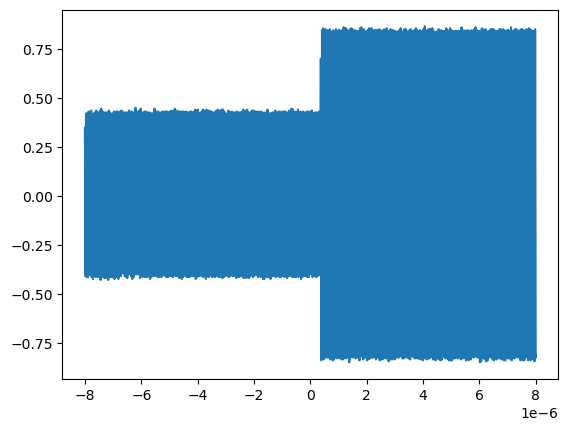

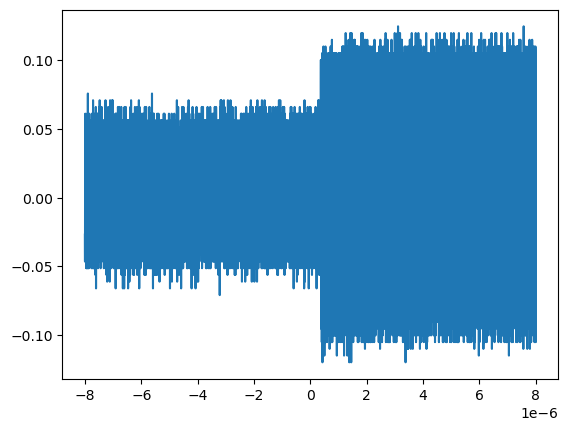

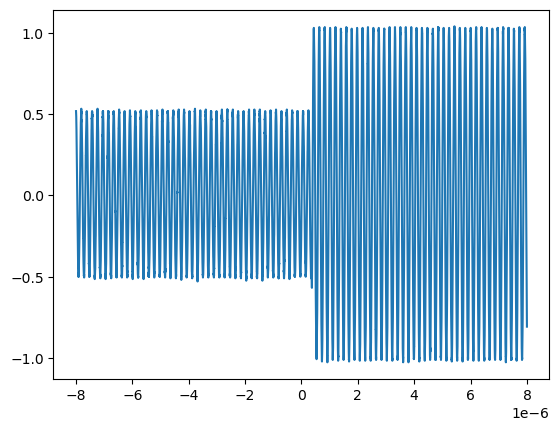

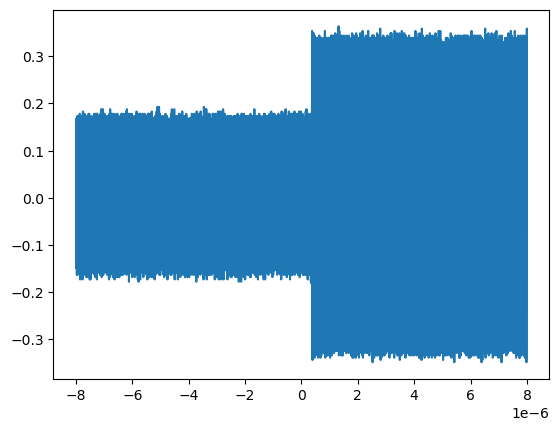

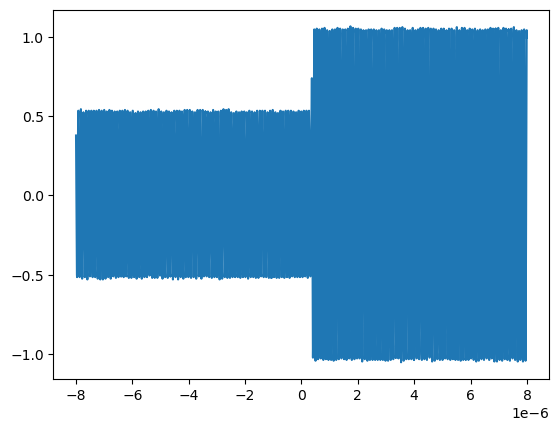

In [101]:
# [ 5.373296 38.923847 33.074005 22.505043 22.217746 43.071298  5.211336
#  35.171034 10.872007  5.61469 ]

def make_t(sample_rate_returned, num_of_points):

    sample_rate = sample_rate_returned / 4
    dt = (1 / sample_rate)
    t = np.arange(-num_of_points / 2, num_of_points / 2, 1) * dt 
    return t

t = make_t(2.5e9, 10000)

for i in range(1, 16):
    ch1 = np.load(f"./data_new/data-{i}.npy")
    print(get_peak_freq(t_new, ch1))
    fig, ax = plt.subplots()
    ax.plot(t, ch1)


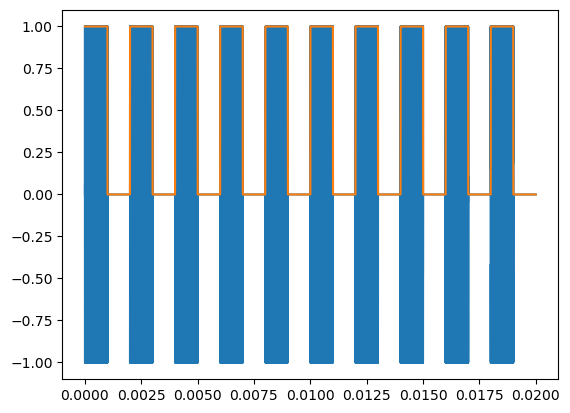

In [60]:
def load_csv_two_channels(csv_file):
    data = np.genfromtxt(csv_file, delimiter=",", skip_header=1)
    t = np.asarray(data[:, 0], dtype=np.float32)
    ch1 = np.asarray(data[:, 1], dtype=np.float32)
    ch2 = np.asarray(data[:, 2], dtype=np.float32)
    return t, ch1, ch2

t, ch1, ch2 = load_csv_two_channels("./waveforms/test_scope_100.csv")
fig, ax = plt.subplots()
ax.plot(t, ch1)
ax.plot(t, ch2)
# ax.set_xlim(0, 1e-5)